In [1]:
import numpy as np
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
vectorizer = TfidfVectorizer()

df = pd.read_csv("../data/quran.csv")

cols = list(df.columns)
cols[0] = 'chapter#' 
cols[1] = 'verse#'
cols[2] = 'd_verse'
cols[3] = 'verse'
cols[9] = 'd_chapter'
cols[10] = 'chapter'
df.columns = cols
df = df.sort_values(by=['chapter#','verse#']).reset_index(drop=True)
df.drop([6459], axis=0, inplace=True)

In [3]:
df.head(50)

,chapter#,verse#,d_verse,verse,22b81fd12c136d4cf67a37de941908d83eaf8e97571c4983f9308d30d52ad8f9,0.25,1.1,١,1.2,d_chapter,chapter,1.3,0.1
0,1,1,بِسۡمِ ٱللَّهِ ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ,بسم الله الرحمٰن الرحيم,803dee27b5a9ddf866112eac2f8a34e5bd83ca08015ec4...,0.25,1,١,2,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
1,1,2,ٱلۡحَمۡدُ لِلَّهِ رَبِّ ٱلۡعَٰلَمِينَ,الحمد لله رب العٰلمين,ef2e84a7a99f9340845888a735cf6950853f9e1a13cff3...,0.25,1,١,3,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
2,1,3,ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ,الرحمٰن الرحيم,fa43107ca02d890e5115053aed9835bfbefb79ffa68464...,0.25,1,١,4,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
3,1,4,مَٰلِكِ يَوۡمِ ٱلدِّينِ,مٰلك يوم الدين,4355fb3e57b0b8b4e47545d28d30b98359fea1a18e5bfc...,0.25,1,١,5,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
4,1,5,إِيَّاكَ نَعۡبُدُ وَإِيَّاكَ نَسۡتَعِينُ,اياك نعبد واياك نستعين,8fc4ad4ff4e86be9abf8b5c66fd47a316b760844456c87...,0.25,1,١,6,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
5,1,6,ٱهۡدِنَا ٱلصِّرَٰطَ ٱلۡمُسۡتَقِيمَ,اهدنا الصرٰط المستقيم,3588b00e5f634a98aad43530808b52caa9b481dad46dda...,0.25,1,١,7,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
6,1,7,صِرَٰطَ ٱلَّذِينَ أَنۡعَمۡتَ عَلَيۡهِمۡ غَيۡرِ...,صرٰط الذين انعمت عليهم غير المغضوب عليهم ولا ا...,2a2c9b6be73c32c7956511168c280f11d1d7c45d877574...,0.25,1,١,8,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
7,2,0,سُورَةُ البَقَرَةِ,سورة البقرة,b9646eafdec422426ae5fbe958306ee6b0a4471328a4f6...,0.25,2,٢,9,سُورَةُ البَقَرَةِ,سورة البقرة,1,0
8,2,0,بِسۡمِ ٱللَّهِ ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ,بسم الله الرحمٰن الرحيم,803dee27b5a9ddf866112eac2f8a34e5bd83ca08015ec4...,0.25,2,٢,10,سُورَةُ البَقَرَةِ,سورة البقرة,1,0
9,2,1,الٓمٓ,الم,49c5355bd921dc0d810e3be457432004847a72d5dbe754...,0.25,2,٢,11,سُورَةُ البَقَرَةِ,سورة البقرة,1,0


In [4]:
vectorized_verses = vectorizer.fit_transform(df['verse'])
hc = AgglomerativeClustering(n_clusters=None, metric="cosine", linkage="complete", distance_threshold= 0)

y = hc.fit_predict(vectorized_verses.toarray())

In [5]:

from scipy.cluster.hierarchy import dendrogram, fcluster

# If needed, refit with compute_distances=True to guarantee distances_ is available
hc = AgglomerativeClustering(
    n_clusters=None,
    metric="cosine",
    linkage="complete",
    distance_threshold=0,
    compute_distances=True
)
y = hc.fit_predict(vectorized_verses.toarray())

def sklearn_model_to_linkage(model):
    counts = np.zeros(model.children_.shape[0]) #Model.children is a 2D array that keeps track of all of the merges
    n_samples = len(model.labels_) #An array same size as number of verses

    for i, merge in enumerate(model.children_):
        count = 0
        for child_idx in merge:
            if child_idx < n_samples: 
                count += 1
            else:
                count += counts[child_idx - n_samples]
        counts[i] = count

    # columns: child1, child2, distance, sample_count
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)
    return linkage_matrix

Z = sklearn_model_to_linkage(hc)

np.save("../data/hc_linkage.npy", Z)
df[["chapter#", "verse#", "chapter", "verse"]].to_csv(
    "../data/hc_verses.csv", index=False
)

Min distance:        0.0000
25th percentile:     0.6394
50th percentile:     0.8013
75th percentile:     0.9321
90th percentile:     1.0000
Max distance:        1.0000

Merges below 0.5:    890
Merges at exactly 1.0: 949


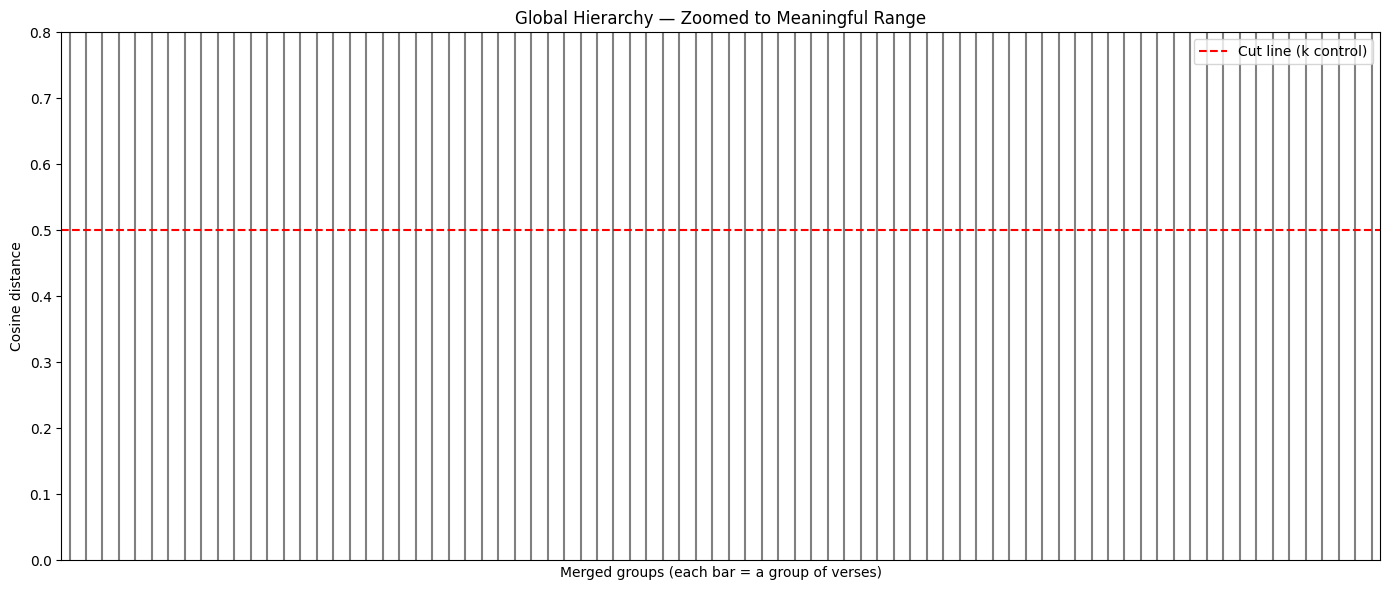

In [6]:
# First, inspect where the meaningful structure actually is
distances = Z[:, 2]
print(f"Min distance:        {distances.min():.4f}")
print(f"25th percentile:     {np.percentile(distances, 25):.4f}")
print(f"50th percentile:     {np.percentile(distances, 50):.4f}")
print(f"75th percentile:     {np.percentile(distances, 75):.4f}")
print(f"90th percentile:     {np.percentile(distances, 90):.4f}")
print(f"Max distance:        {distances.max():.4f}")
print(f"\nMerges below 0.5:    {(distances < 0.5).sum()}")
print(f"Merges at exactly 1.0: {(distances == 1.0).sum()}")

# Global dendrogram — zoom into meaningful range (low distances)
# color_threshold draws a horizontal cut line and colours clusters below it
plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=80,
    no_labels=True,
    color_threshold=0.5,       # cut line at cosine distance 0.5
    above_threshold_color="grey"  # everything above 0.5 greyed out
)
plt.title("Global Hierarchy — Zoomed to Meaningful Range")
plt.xlabel("Merged groups (each bar = a group of verses)")
plt.ylabel("Cosine distance")
plt.ylim(0, 0.8)   # hide the flat wall at 1.0
plt.axhline(y=0.5, color='red', linestyle='--', label='Cut line (k control)')
plt.legend()
plt.tight_layout()
plt.show()

Cluster 518 has 21 verses


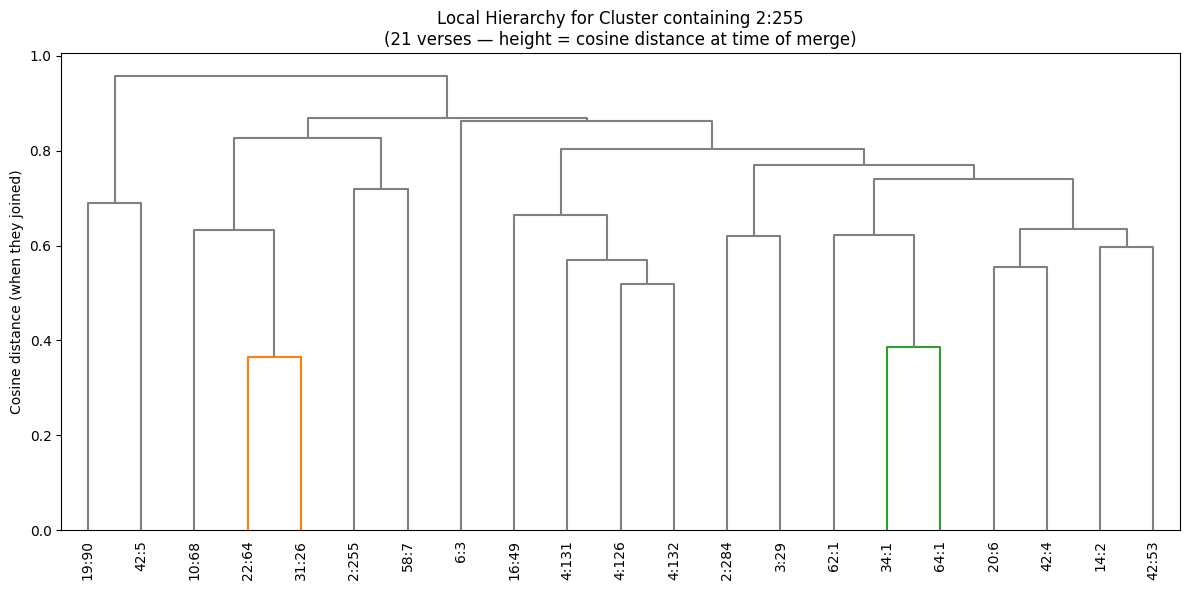


Verses in this cluster:
      chapter#  verse#                                                                                                                                                                                                                                           verse
263          2     255  الله لا الٰه الا هو الحي القيوم لا تاخذه سنة ولا نوم له ما في السمٰوٰت وما في الارض من ذا الذي يشفع عنده الا باذنه يعلم ما بين ايديهم وما خلفهم ولا يحيطون بشيء من علمه الا بما شاء وسع كرسيه السمٰوٰت والارض ولا يوده حفظهما وهو العلي العظيم
292          2     284                                                                                                             لله ما في السمٰوٰت وما في الارض وان تبدوا ما في انفسكم او تخفوه يحاسبكم به الله فيغفر لمن يشاء ويعذب من يشاء والله علىٰ كل شيء قدير
325          3      29                                                                                                                                           قل ان تخفوا ما في صدوركم 

In [7]:
# Localised dendrogram — shows TRUE merge order within a cluster
# by re-clustering only that subset of verses

from scipy.cluster.hierarchy import dendrogram as _dendrogram

target_chapter = 2
target_verse   = 255

# 1. Find the verse's row position
match = df[(df["chapter#"] == target_chapter) & (df["verse#"] == target_verse)]
if match.empty:
    print("Verse not found.")
else:
    idx = match.index[0]

    # 2. Cut the full tree at k clusters to find cluster membership
    from scipy.cluster.hierarchy import fcluster
    k = 1000
    labels_k = fcluster(Z, t=k, criterion="maxclust")

    cluster_id  = labels_k[idx]
    member_idx  = np.where(labels_k == cluster_id)[0]
    print(f"Cluster {cluster_id} has {len(member_idx)} verses")

    if len(member_idx) < 2:
        print("Cluster has only 1 verse — nothing to plot.")
    elif len(member_idx) > 200:
        print(f"Cluster too large ({len(member_idx)} verses) to plot clearly. Try a higher k.")
    else:
        # 3. Re-cluster ONLY this subset so we get the true local merge order
        subset_dense = vectorized_verses[member_idx].toarray()

        hc_local = AgglomerativeClustering(
            n_clusters=None,
            metric="cosine",
            linkage="complete",
            distance_threshold=0,
            compute_distances=True
        )
        hc_local.fit(subset_dense)
        Z_local = sklearn_model_to_linkage(hc_local)

        # 4. Build labels: "S:V" for each member, highlight target verse
        local_labels = []
        for pos in member_idx:
            row = df.iloc[pos]
            label = f"{int(row['chapter#'])}:{int(row['verse#'])}"
            local_labels.append(label)


        plt.figure(figsize=(max(12, len(member_idx) * 0.4), 6))
        _dendrogram(
            Z_local,
            labels=local_labels,
            leaf_rotation=90,
            color_threshold=0.5,
            above_threshold_color="grey"
        )
        plt.title(
            f"Local Hierarchy for Cluster containing {target_chapter}:{target_verse}\n"
            f"({len(member_idx)} verses — height = cosine distance at time of merge)"
        )
        plt.ylabel("Cosine distance (when they joined)")
        plt.tight_layout()
        plt.show()

        # 5. Also show the flat list with merge insight
        print("\nVerses in this cluster:")
        print(df.iloc[member_idx][["chapter#", "verse#", "verse"]].to_string())

cluster size: 116 fig is None: False
Cluster 8 has 116 verses.
[   0    2    8  295  498  676  798  965 1173 1380] 116


C:\Users\zainz\AppData\Local\Temp\ipykernel_46056\1399733745.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


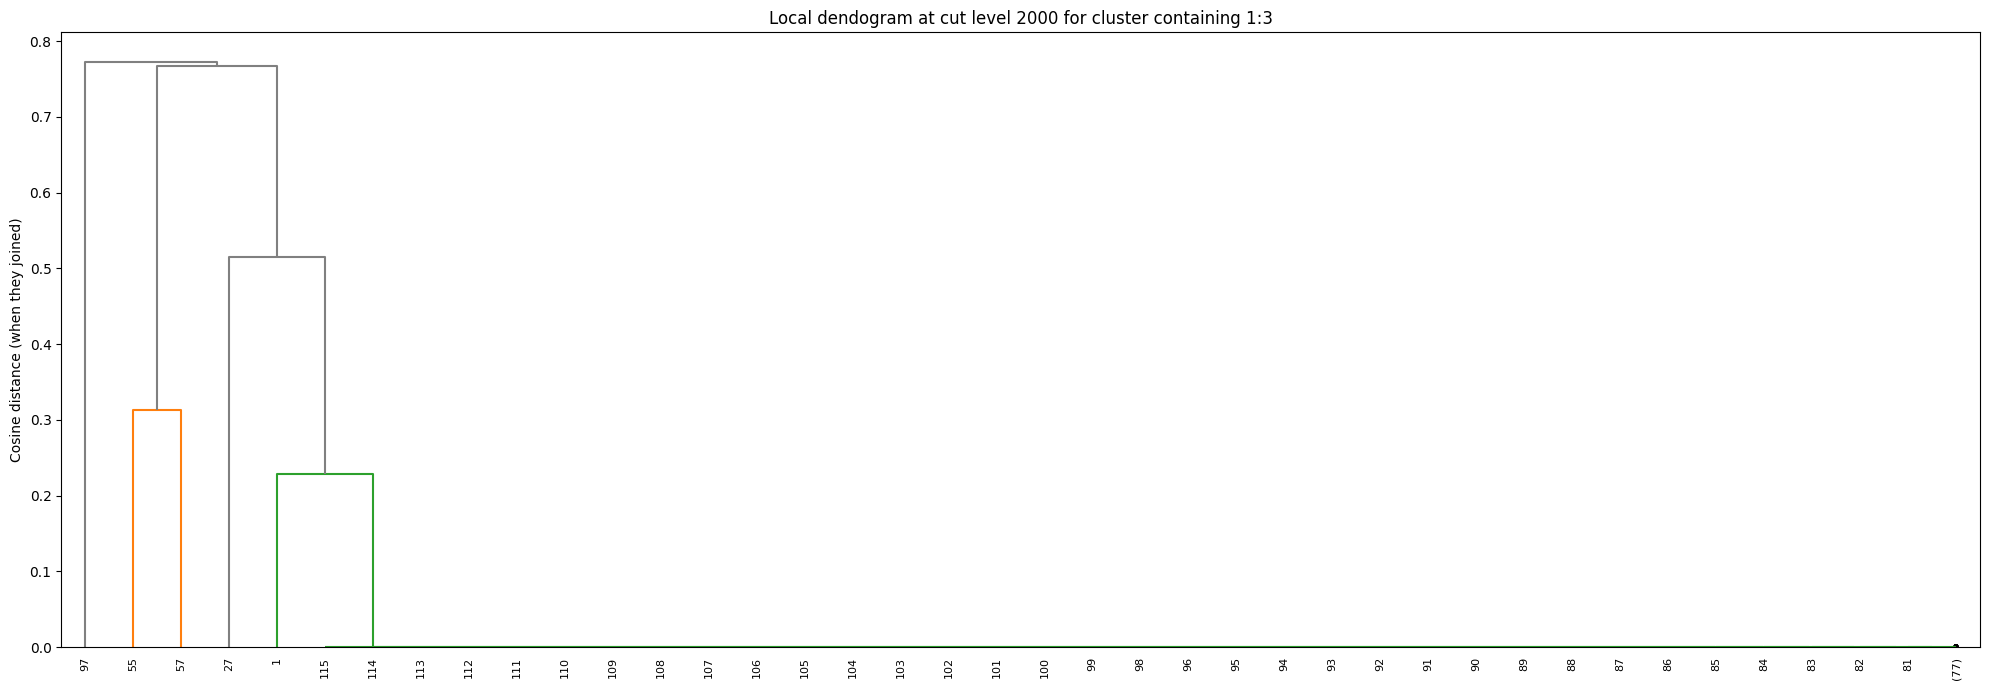

In [22]:
import os
import sys
import importlib

sys.path.append(os.path.abspath(".."))  # add project root
import utils
importlib.reload(utils)
from utils import build_local_dendrogram

result = build_local_dendrogram(
    1, 3, Z, k=2000, vectorized_verses=vectorized_verses, df=df
)

# Support both older (fig, member_idx) and newer (fig, member_idx, msg) returns
if len(result) == 3:
    fig, member_idx, msg = result
else:
    fig, member_idx = result
    msg = "No message returned (older function version)."

print("cluster size:", len(member_idx), "fig is None:", fig is None)
print(msg)
if fig is not None:
    fig.show()
print(member_idx[:10], len(member_idx))